# Model Experimentation Per Horizon

This notebook focuses on `target_aqi_day1`.

## Approach

1. Load the modeling dataframe and create chronological train/validation/test splits.
2. Experiment with **Random Forest** using all engineered features (excluding `ts`).
3. Apply **RFECV** and evaluate the selected feature set.
4. Perform hyperparameter tuning and select the best Random Forest configuration.
5. Repeat the same process for **Ridge Regression** and **MLP**.
6. Compare the best configuration from each model type and select the overall winner.
7. Evaluate the final winner on the test set.
8. Retrain the winning model on the available training data and generate Day 1 predictions for the full dataframe.
9. Store the Day 1 predictions as a new feature for use in subsequent horizons.
10. Use the same winning model type for the next horizon.

In [134]:
import pandas as pd
import numpy as np
from keras import Sequential, Input
from keras.src.optimizers import Adam
from keras.src.layers import Dense, Dropout
from keras.src.callbacks import EarlyStopping
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
import tensorflow as tf
from sklearn.model_selection import TimeSeriesSplit
from tensorflow.python.keras.regularizers import l2

from notebooks.eda.utils import select_features_with_rfecv
from src.common.schemas import DeepLearningFitParamSchema
from src.common.constants import ALL_TRAINING_FEATURES, ALL_LOG_TRANSFORM_FEATURES
from src.modeling.data_utils import load_modeling_data, split_modeling_data, train_and_evaluate_model, preprocess_data

In [ ]:
df = load_modeling_data()

## Experiment 0 — Feature Distribution & Preprocessing

Analyze the to determine the required preprocessing before experimenting with Ridge Regression and MLP.

- Analyze feature distributions, scales, and skewness.
- Identify features requiring transformation.
- Determine the appropriate scaling strategy.
- Finalize the preprocessing pipeline for subsequent model experiments.

In [ ]:
train_df, val_df, test_df = split_modeling_data(df)

In [ ]:
X_train = train_df[ALL_TRAINING_FEATURES].copy()

distribution_analysis = pd.DataFrame({
    "skewness": X_train.skew(),
})

distribution_analysis.round(3)

**Observation:** The feature distributions are largely consistent with the previous analysis. Most features show similar skewness, while `aqi_roll_std_3` and `aqi_roll_std_7` remain strongly right-skewed at **4.142** and **3.223**, respectively. Since these features are already included in the existing `log1p` transformation, no additional preprocessing changes are required based on skewness.

## Experiment 1 — Day 1 Model Experimentation

This experiment focuses exclusively on `target_aqi_day1`.

The goal is to determine the best-performing model type and configuration for Day 1 by:

1. Using all engineered features except `ts`.
2. Experimenting with Random Forest, Ridge Regression, and MLP.
3. Applying feature selection and hyperparameter tuning within each model type.
4. Comparing the best configurations and selecting the overall winner.
5. Evaluating the final winner on the test set.
6. Using the finalized Day 1 model to generate predictions for the full dataframe, which will be stored as a new feature for the next experiment.

In [132]:
target_label = ["target_aqi_day1"]

### 1.1 — Random Forest Experiment

Experiment with Random Forest for `target_aqi_day1` using all available training features.

- Train a baseline configuration.
- Apply RFECV for feature selection.
- Evaluate the RFECV-selected feature set.
- Perform hyperparameter tuning.
- Select the best Random Forest configuration based on validation performance.

In [ ]:
random_forest_regressor_params = {
    "n_estimators": 400,
    "max_depth": 20,
    "min_samples_split": 2,
    "min_samples_leaf": 2,
    "max_features": 1.0,
    "max_samples": 1.0,
    "random_state": 42,
    "n_jobs": -1,
}

In [ ]:
rf_base_model = RandomForestRegressor(
    **random_forest_regressor_params
)

rf_base_model, (rf_base_rmse, rf_base_mae, rf_base_r2) = train_and_evaluate_model(train_df, val_df,
                                                                                  label="Random Forest Base Model", toggle_evaluate_print=True, disable_plot=True,
                                                                                  baseline=ALL_TRAINING_FEATURES,
                                                                                  model=rf_base_model,
                                                                                  output_labels=target_label
                                                                                  )

**Observation:** The baseline Random Forest achieved a validation **RMSE of 14.8916**, **MAE of 9.8196**, and **R² of 0.8598** for `target_aqi_day1`. This provides a strong baseline for comparing the RFECV-selected feature set and subsequent hyperparameter tuning.

In [ ]:
rf_base_model_rfecv = RandomForestRegressor(
    **random_forest_regressor_params
)

select_features_with_rfecv(ALL_TRAINING_FEATURES, train_df, val_df, output_labels=target_label, model=rf_base_model_rfecv)

**Observation:** RFECV selected **29 features**, but its O₃ selections are inconsistent with the intended feature-group structure. It retained `o3_lag_3` and the rolling features while excluding `o3_lag_1` and `o3_lag_2`. To preserve a balanced O₃ temporal block, the selected set will be adjusted by restoring the missing O₃ lag features and removing `o3_lag_3` where necessary.

In [ ]:
RFECV_SELECTED_FEATURES_RF = [
    "aqi_today",
    "aqi_roll_std_3",
    "aqi_roll_std_7",
    "pm25_today",
    "pm25_lag_1",
    "pm25_roll_mean_7",
    "pm25_roll_std_3",
    "pm10_today",
    "pm10_lag_1",
    "pm10_roll_std_3",
    "pm10_roll_std_7",
    "o3_today",
    "o3_lag_1",
    "o3_roll_mean_7",
    "o3_roll_std_3",
    "temp_today",
    "temp_lag_1",
    "humidity_today",
    "humidity_lag_1",
    "wind_spd_today",
    "wind_spd_lag_1",
    "pressure_today",
    "dew_pt_today",
    "dew_pt_lag_1",
    "co_today",
    "so2_today",
    "no2_today",
    "aqi_change_rate",
]

rf_base_model_rfecv = RandomForestRegressor(
    **random_forest_regressor_params
)

rf_base_model_rfecv, (rf_base_rmse_rfecv, rf_base_mae_rfecv, rf_base_r2_rfecv) = train_and_evaluate_model(train_df, val_df,
                                                                                  label="Random Forest Base Model RFECV",
                                                                                  disable_plot=True,
                                                                                  baseline=RFECV_SELECTED_FEATURES_RF,
                                                                                  model=rf_base_model_rfecv,
                                                                                  output_labels=target_label,
                                                                                  compare_model=("Random Forest Base Model",
                                                                                                 (rf_base_rmse, rf_base_mae,
                                                                                                  rf_base_r2))
                                                                                  )

**Observation:** The RFECV-selected feature set provides a **small but consistent improvement** over the baseline, reducing RMSE from **14.8916 → 14.8286**, MAE from **9.8196 → 9.7718**, and increasing R² from **0.8598 → 0.8610**. Although the improvement is minor, the reduced feature set is preferable due to its lower complexity. Next, the RFECV-selected features will be used for **Random Forest hyperparameter tuning**.

In [ ]:
random_forest_regressor_params_2 = random_forest_regressor_params.copy()

random_forest_regressor_params_2["max_features"] = 0.8

rf_base_model_rfecv_2 = RandomForestRegressor(
    **random_forest_regressor_params_2
)

rf_base_model_rfecv_2, (rf_base_rmse_rfecv_2, rf_base_mae_rfecv_2, rf_base_r2_rfecv_2) = train_and_evaluate_model(train_df,
                                                                                  val_df,
                                                                                  label="Random Forest Base Model RFECV v2",
                                                                                  disable_plot=True,
                                                                                  baseline=RFECV_SELECTED_FEATURES_RF,
                                                                                  model=rf_base_model_rfecv_2,
                                                                                  output_labels=target_label,
                                                                                  compare_model=(
                                                                                      "Random Forest Base Model RFECV",
                                                                                      (rf_base_rmse_rfecv, rf_base_mae_rfecv,
                                                                                       rf_base_r2_rfecv)
                                                                                    )
                                                                                  )

**Observation:** The tuned Random Forest achieved a validation **RMSE of 14.6841**, **MAE of 9.7437**, and **R² of 0.8637**. The main improvement came from reducing `max_features` to `0.8`; further tuning of the remaining hyperparameters provided little to no benefit. Although the R² target of 0.90 was not reached, the model remains within the desired RMSE and MAE ranges. This configuration will be retained as the best Random Forest result for comparison with Ridge Regression and MLP.

### 1.2 — Ridge Regression Experiment

Experiment with Ridge Regression for `target_aqi_day1` using the selected Random Forest feature set.

- Train a baseline configuration with the required preprocessing.
- Apply RFECV for feature selection.
- Evaluate the RFECV-selected feature set.
- Perform hyperparameter tuning.
- Select the best Ridge Regression configuration based on validation performance.

In [ ]:
ridge_regressor_params = {
    "alpha": 10.0,
    "fit_intercept": True,
    "solver": "auto",
    "tol": 1e-4,
    "max_iter": 5000,
}

train_df, val_df, test_df = preprocess_data(train_df, val_df, test_df, log_features=ALL_LOG_TRANSFORM_FEATURES, scale_features=ALL_TRAINING_FEATURES)

In [ ]:
ridge_base_model = Ridge(
    **ridge_regressor_params
)

ridge_base_model, (ridge_base_rmse, ridge_base_mae, ridge_base_r2) = train_and_evaluate_model(train_df,
                                                                                  val_df,
                                                                                  label="Ridge Regression Base Model",
                                                                                  disable_plot=True,
                                                                                  baseline=ALL_TRAINING_FEATURES,
                                                                                  model=ridge_base_model,
                                                                                  output_labels=target_label,
                                                                                  compare_model=(
                                                                                      "Random Forest Base Model RFECV v2",
                                                                                      (rf_base_rmse_rfecv_2, rf_base_mae_rfecv_2,
                                                                                       rf_base_r2_rfecv_2)
                                                                                    )
                                                                                  )

**Observation:** Ridge Regression outperformed the tuned Random Forest, achieving **14.29 RMSE**, **10.34 MAE**, and **0.871 R²**. While RMSE and R² improved noticeably, MAE remains slightly above the target of <10. Ridge will be evaluated further with RFECV and hyperparameter tuning.

In [ ]:
ridge_base_model_rfecv = Ridge(
    **ridge_regressor_params
)

select_features_with_rfecv(ALL_TRAINING_FEATURES, train_df, val_df, output_labels=target_label, model=ridge_base_model_rfecv)

**Observation:** RFECV selected a reduced feature set, but some selections cannot be applied directly due to feature-group dependencies. `aqi_lag_1` will be retained alongside the selected AQI features. For `o3`, `o3_today`, `o3_lag_2`, and `o3_roll_mean_7` will be restored alongside the selected features. Pollutants such as `co`, `so2`, and `no2` will also be retained. The resulting adjusted feature set will be evaluated with Ridge Regression.

In [ ]:
RFECV_SELECTED_FEATURES_RIDGE = [
    "aqi_today",
    "aqi_lag_1",
    "aqi_lag_2",
    "aqi_roll_mean_7",

    "pm25_today",
    "pm25_lag_1",
    "pm25_roll_mean_3",
    "pm25_roll_mean_7",
    "pm25_roll_std_3",

    "pm10_today",
    "pm10_lag_1",
    "pm10_lag_2",
    "pm10_lag_3",
    "pm10_roll_mean_3",
    "pm10_roll_mean_7",
    "pm10_roll_std_3",

    "o3_today",
    "o3_lag_1",
    "o3_lag_2",
    "o3_roll_mean_3",
    "o3_roll_mean_7",

    "temp_today",
    "wind_spd_today",

    "co_today",
    "so2_today",
    "no2_today",
]

ridge_base_model_rfecv = Ridge(
    **ridge_regressor_params
)

ridge_base_model_rfecv, (ridge_base_rmse_rfecv , ridge_base_mae_rfecv , ridge_base_r2_rfecv ) = train_and_evaluate_model(
      train_df, val_df,
      label="Ridge Regression Base Model RFECV",
      disable_plot=True,
      baseline=RFECV_SELECTED_FEATURES_RIDGE,
      model=ridge_base_model_rfecv,
      output_labels=target_label,
      compare_model=("Ridge Regression Base Model", (ridge_base_rmse, ridge_base_mae,ridge_base_r2))
      )

**Observation:** RFECV provided a meaningful improvement, reducing RMSE from **14.29 → 14.09** and MAE from **10.34 → 10.28**, while R² increased from **0.871 → 0.875**. The reduced feature set will be used for the next Ridge hyperparameter tuning stage.

In [ ]:
ridge_regressor_params_2 = ridge_regressor_params.copy()

ridge_regressor_params_2["alpha"] = 5.0
ridge_regressor_params_2["solver"] = "lsqr"
ridge_regressor_params_2["tol"] = 1e-5

ridge_base_model_rfecv_2 = Ridge(
    **ridge_regressor_params_2
)

ridge_base_model_rfecv_2, (ridge_base_rmse_rfecv_2 , ridge_base_mae_rfecv_2 , ridge_base_r2_rfecv_2 ) = train_and_evaluate_model(
      train_df, val_df,
      label="Ridge Regression Base Model RFECV v2",
      disable_plot=True,
      baseline=RFECV_SELECTED_FEATURES_RIDGE,
      model=ridge_base_model_rfecv_2,
      output_labels=target_label,
      compare_model=("Ridge Regression Base Model RFECV", (ridge_base_rmse_rfecv, ridge_base_mae_rfecv,ridge_base_r2_rfecv))
      )

**Observation:** Hyperparameter tuning produced a modest improvement, with the best configuration using `alpha=5.0`, `solver="lsqr"`, and `tol=1e-5`. RMSE improved from **14.09 → 14.06**, MAE from **10.28 → 10.24**, and R² from **0.87453 → 0.87497**. The remaining parameters provided no meaningful improvement. Overall, tuning offered only a small additional gain.

### 1.3 — MLP Experiment

Experiment with MLP for `target_aqi_day1` using the selected feature set.

- Train a baseline configuration with the required preprocessing.
- Apply RFECV for feature selection.
- Evaluate the RFECV-selected feature set.
- Perform hyperparameter tuning.
- Select the best MLP configuration based on validation performance.

In [ ]:
tf.keras.utils.set_random_seed(42)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
)

mlp_base_model_fit_params: DeepLearningFitParamSchema = {
    "epochs": 500,
    "batch_size": 32,
    "callbacks": [early_stopping],
    "verbose": 1
}

In [ ]:
mlp_base_model = Sequential([
    Input(shape=(49,)),
    Dense(
        8,
        activation="relu",
        kernel_regularizer=l2(1e-4),
    ),
    Dropout(0.15),
    Dense(1, activation="linear"),
])

mlp_base_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="mse",
)

mlp_base_model, (mlp_base_rmse, mlp_base_mae, mlp_base_r2) = train_and_evaluate_model(train_df, val_df,
                         label="MLP Base Model", disable_plot=True, baseline=ALL_TRAINING_FEATURES, model=mlp_base_model,
                         output_labels=target_label,
                         compare_model=("Ridge Regression Base Model RFECV", (
                                        ridge_base_rmse_rfecv_2, ridge_base_mae_rfecv_2, ridge_base_r2_rfecv_2
                         )),
                         deep_learning=mlp_base_model_fit_params)

**Observation:** The MLP performed substantially worse than Ridge Regression, achieving **16.92 RMSE**, **13.04 MAE**, and **0.819 R²**, compared with Ridge's **14.06 RMSE**, **10.24 MAE**, and **0.875 R²**. With preprocessing and scaling already applied, the base MLP currently shows no advantage over Ridge and will require further tuning.

In [ ]:
mlp_base_model_rfecv = Sequential([
    Input(shape=(26,)),
    Dense(
        8,
        activation="relu",
        kernel_regularizer=l2(1e-4),
    ),
    Dropout(0.15),
    Dense(1, activation="linear"),
])

mlp_base_model_rfecv.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="mse",
)

mlp_base_model_rfecv, (mlp_base_rmse_rfecv, mlp_base_mae_rfecv, mlp_base_r2_rfecv) = train_and_evaluate_model(train_df, val_df,
                         label="MLP Base Model RFECV", disable_plot=True, baseline=RFECV_SELECTED_FEATURES_RIDGE, model=mlp_base_model_rfecv,
                         output_labels=target_label,
                         compare_model=("Ridge Regression Base Model RFECV", (
                                        ridge_base_rmse_rfecv_2, ridge_base_mae_rfecv_2, ridge_base_r2_rfecv_2
                         )),
                         deep_learning=mlp_base_model_fit_params)

**Observation:** Using the Ridge RFECV-selected feature set improved the MLP compared with the base MLP, reducing RMSE from **16.92 → 14.81**, MAE from **13.04 → 11.36**, and increasing R² from **0.819 → 0.861**. However, it still underperforms Ridge Regression (**14.06 RMSE**, **10.24 MAE**, **0.875 R²**).

In [ ]:
mlp_base_model_rfecv_2 = Sequential([
    Input(shape=(26,)),
    Dense(
        128,
        activation="relu",
        kernel_regularizer=l2(1e-3),
    ),
    Dropout(0.15),
    Dense(1, activation="linear"),
])

mlp_base_model_rfecv_2.compile(
    optimizer=Adam(learning_rate=5e-3),
    loss="huber",
)

mlp_base_model_rfecv_2, (mlp_base_rmse_rfecv_2, mlp_base_mae_rfecv_2, mlp_base_r2_rfecv_2) = train_and_evaluate_model(train_df, val_df,
                         label="MLP Base Model RFECV v2", disable_plot=True, baseline=RFECV_SELECTED_FEATURES_RIDGE, model=mlp_base_model_rfecv_2,
                         output_labels=target_label,
                         compare_model=("Ridge Regression Base Model RFECV", (
                                        ridge_base_rmse_rfecv_2, ridge_base_mae_rfecv_2, ridge_base_r2_rfecv_2
                         )),
                         deep_learning=mlp_base_model_fit_params)

**Observation:** MLP tuning produced a substantial improvement, with the best configuration achieving **12.52 RMSE**, **9.33 MAE**, and **0.901 R²**, outperforming Ridge Regression (**14.06 RMSE**, **10.24 MAE**, **0.875 R²**). Increasing the first hidden layer up to **128 neurons** improved performance, after which gains diminished. Adding a second hidden layer degraded performance. A **1e-3 L2 regularizer**, **5e-3 learning rate**, and **Huber loss** provided the best results. The MLP successfully exceeded the **0.90 R²** target while also achieving **RMSE <15** and **MAE <10**.

## Experiment 2 — Remaining Horizon Model Experimentation

This experiment focuses exclusively on `target_aqi_day2`, `target_aqi_day3`, and `target_aqi_day4`.

The goal is to develop models for the remaining horizons while keeping the model type consistent with the winning model from Experiment 1.

### 2.1 — Day 2 Feature Experiment

Experiment with `target_aqi_day2` using the finalized MLP configuration and the available engineered features.

- Train the MLP using the available Day 2 features.
- Apply RFECV using Ridge Regression to identify a reduced feature set.
- Evaluate the MLP using the RFECV-selected features.
- Keep the RFECV feature set only if it improves validation performance; otherwise, retain the full feature set.

In [146]:
target_label = ["target_aqi_day2"]

In [155]:
mlp_base_model_2 = Sequential([
    Input(shape=(49,)),
    Dense(
        128,
        activation="relu",
        kernel_regularizer=l2(1e-3),
    ),
    Dropout(0.15),
    Dense(1, activation="linear"),
])

mlp_base_model_2.compile(
    optimizer=Adam(learning_rate=5e-3),
    loss="huber",
)

mlp_base_model_2, (mlp_base_rmse_2, mlp_base_mae_2, mlp_base_r2_2) = train_and_evaluate_model(train_df, val_df,
                         label="MLP Base Model Day 2", disable_plot=True, baseline=ALL_TRAINING_FEATURES,
                         model=mlp_base_model_2, output_labels=target_label,
                         toggle_evaluate_print=True,
                         deep_learning=mlp_base_model_fit_params)

Epoch 1/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 144.7962 - val_loss: 131.6574
Epoch 2/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 96.2027 - val_loss: 68.3794
Epoch 3/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 62.9974 - val_loss: 54.2899
Epoch 4/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 52.5774 - val_loss: 46.1999
Epoch 5/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 41.5386 - val_loss: 37.6612
Epoch 6/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 34.3437 - val_loss: 33.0835
Epoch 7/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 31.0071 - val_loss: 31.0427
Epoch 8/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 29.2278 - val_loss: 29.8597
Epoch 9/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 27.4372 - val_loss: 27.6503
Epoch 10/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 26.1621 - val_loss: 27.0034
Epoch 11/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 24.3538 - val_loss: 25.9790
Epoch 12/500
32/32 ━━━━━━━━━━━━━━━━━━━

**Observation:** Using the reduced and expanded feature set improved Day 2 performance slightly compared with the previous experiment, achieving **27.91 RMSE**, **20.05 MAE**, and **0.515 R²**. However, Day 2 prediction remains substantially weaker than Day 1, indicating that the currently available features provide limited predictive information for the longer forecasting horizon.

Selected features:
aqi_today
aqi_lag_1
aqi_roll_mean_3
aqi_roll_mean_7
pm25_today
pm25_roll_mean_7
pm10_lag_2
pm10_roll_mean_3
pm10_roll_mean_7
o3_today
o3_roll_mean_3
o3_roll_mean_7
wind_spd_today
dew_pt_lag_1
co_today
month

Selected feature count: 16


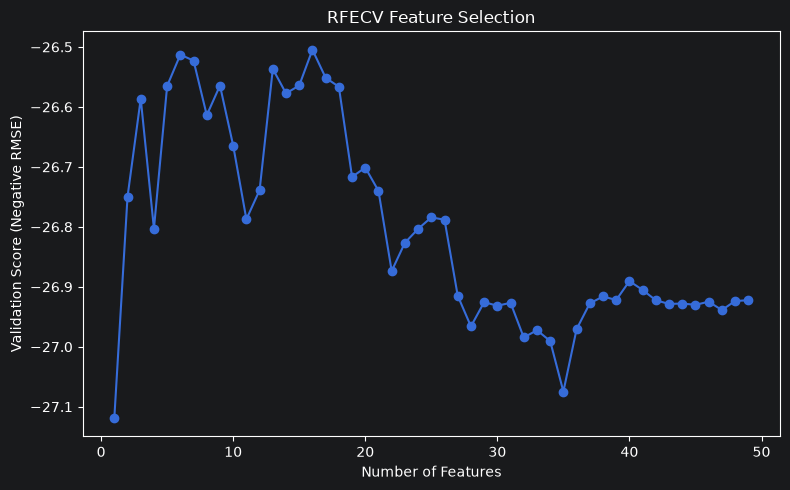

In [156]:
ridge_base_model_rfecv = Ridge(
    **ridge_regressor_params
)

select_features_with_rfecv(ALL_TRAINING_FEATURES, train_df, val_df, output_labels=target_label, model=ridge_base_model_rfecv)

**Observation:** RFECV selected **16 features**, providing a more substantial feature set than the previous selection. The selected features cover AQI history, PM2.5, PM10, O₃, weather, CO, and seasonal information. Since the selected set does not violate the required feature-group dependencies, it will be evaluated directly with the finalized MLP.

In [178]:
MLP_DAY_2_RFECV_FEATURES = [
  "aqi_today",
  "aqi_lag_1",
  "aqi_lag_2",
  "aqi_lag_3",
  "aqi_roll_mean_3",
  "aqi_roll_mean_7",

  "pm25_today",
  "pm25_lag_1",
  "pm25_lag_2",
  "pm25_lag_3",
  "pm25_roll_mean_7",

  "o3_today",
  "o3_lag_1",
  "o3_lag_2",
  "o3_roll_mean_7",

  "pm10_today",
  "pm10_lag_1",
  "pm10_roll_mean_7",

  "co_today",
  "so2_today",
  "no2_today",

  "temp_today",
  "temp_lag_1",
]

mlp_base_model_2_rfecv = Sequential([
    Input(shape=(23,)),
    Dense(
        128,
        activation="relu",
        kernel_regularizer=l2(1e-3),
    ),
    Dropout(0.15),
    Dense(1, activation="linear"),
])

mlp_base_model_2_rfecv.compile(
    optimizer=Adam(learning_rate=5e-3),
    loss="huber",
)

mlp_base_model_2_rfecv, (mlp_base_rmse_2_rfecv, mlp_base_mae_2_rfecv, mlp_base_r2_2_rfecv) = train_and_evaluate_model(train_df,
                         val_df, label="MLP Base Model Day 2 RFECV", disable_plot=True, baseline=MLP_DAY_2_RFECV_FEATURES,
                         model=mlp_base_model_2_rfecv, output_labels=target_label,
                         compare_model=("MLP Base Model Day 2", (
                                        mlp_base_rmse_2, mlp_base_mae_2, mlp_base_r2_2
                         )),
                         deep_learning=mlp_base_model_fit_params)

Epoch 1/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 147.5513 - val_loss: 138.8533
Epoch 2/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 113.4568 - val_loss: 91.0411
Epoch 3/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 73.3481 - val_loss: 62.1224
Epoch 4/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 64.8159 - val_loss: 58.4893
Epoch 5/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 57.2225 - val_loss: 51.7574
Epoch 6/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 48.2274 - val_loss: 45.3892
Epoch 7/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 38.8762 - val_loss: 41.3376
Epoch 8/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 34.3263 - val_loss: 38.6677
Epoch 9/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 31.7258 - val_loss: 34.8501
Epoch 10/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 29.0614 - val_loss: 31.1865
Epoch 11/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 27.1950 - val_loss: 29.1965
Epoch 12/500
32/32 ━━━━━━━━━━━━━━━━━━

,Target,MLP Base Model Day 2 RMSE,MLP Base Model Day 2 MAE,MLP Base Model Day 2 R²,MLP Base Model Day 2 RFECV RMSE,MLP Base Model Day 2 RFECV MAE,MLP Base Model Day 2 RFECV R²
0,target_aqi_day2,27.913414,20.050602,0.515331,25.592854,18.225764,0.592567
1,Mean,27.913414,20.050602,0.515331,25.592854,18.225764,0.592567


**Observation:** The RFECV-selected feature set provided a meaningful improvement, reducing RMSE from **27.91 → 25.59**, MAE from **20.05 → 18.23**, and increasing R² from **0.515 → 0.593**. However, Day 2 performance remains considerably weaker than Day 1, indicating that the available features still provide limited predictive information at the longer forecasting horizon.

### 2.2 — Day 3 Feature Experiment

Experiment with `target_aqi_day3` using the finalized MLP configuration and the available engineered features.

- Train the MLP using the available Day 3 features.
- Apply RFECV using Ridge Regression to identify a reduced feature set.
- Evaluate the MLP using the RFECV-selected features.
- Keep the RFECV feature set only if it improves validation performance; otherwise, retain the full feature set.

In [179]:
target_label = ["target_aqi_day3"]

In [182]:
mlp_base_model_3 = Sequential([
    Input(shape=(49,)),
    Dense(
        128,
        activation="relu",
        kernel_regularizer=l2(1e-3),
    ),
    Dropout(0.15),
    Dense(1, activation="linear"),
])

mlp_base_model_3.compile(
    optimizer=Adam(learning_rate=5e-3),
    loss="huber",
)

mlp_base_model_3, (mlp_base_rmse_3, mlp_base_mae_3, mlp_base_r2_3) = train_and_evaluate_model(train_df, val_df,
                         label="MLP Base Model Day 3", disable_plot=True, baseline=ALL_TRAINING_FEATURES,
                         model=mlp_base_model_3, output_labels=target_label,
                         toggle_evaluate_print=True,
                         deep_learning=mlp_base_model_fit_params)

Epoch 1/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 144.7396 - val_loss: 133.1256
Epoch 2/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 96.7736 - val_loss: 72.0751
Epoch 3/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 63.6259 - val_loss: 57.0788
Epoch 4/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 54.4869 - val_loss: 50.1642
Epoch 5/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 43.6518 - val_loss: 42.9472
Epoch 6/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 37.6759 - val_loss: 38.2657
Epoch 7/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 33.5696 - val_loss: 35.1430
Epoch 8/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 31.8954 - val_loss: 32.7255
Epoch 9/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 30.4013 - val_loss: 30.5680
Epoch 10/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 28.6470 - val_loss: 29.6034
Epoch 11/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 27.8776 - val_loss: 29.0102
Epoch 12/500
32/32 ━━━━━━━━━━━━━━━━━━━

**Observation:** The Day 3 MLP achieved **31.45 RMSE**, **23.34 MAE**, and **0.418 R²**. Performance is substantially weaker than Day 2, indicating that predictive accuracy continues to decline as the forecasting horizon increases. The model will be evaluated with RFECV to determine whether a more focused feature set can improve performance.

Selected features:
aqi_today
pm25_today
pm25_roll_mean_7
dew_pt_today
month

Selected feature count: 5


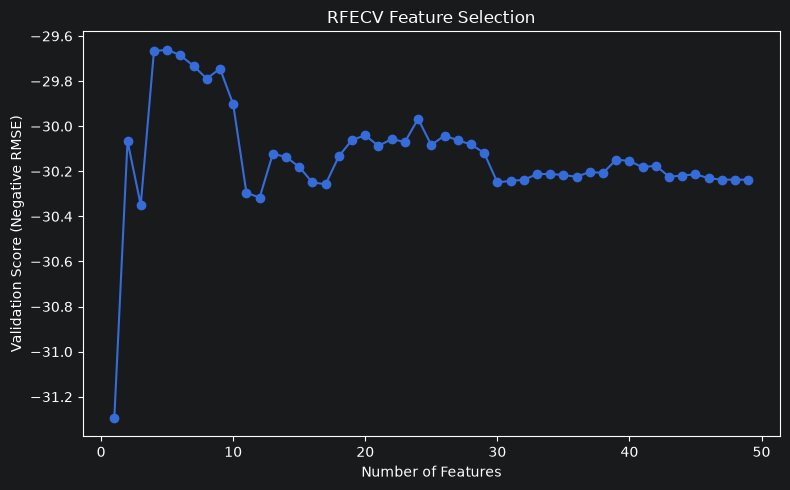

In [181]:
ridge_base_model_rfecv = Ridge(
    **ridge_regressor_params
)

select_features_with_rfecv(ALL_TRAINING_FEATURES, train_df, val_df, output_labels=target_label, model=ridge_base_model_rfecv)

**Observation:** RFECV selected only **5 features**: `aqi_today`, `pm25_today`, `pm25_roll_mean_7`, `dew_pt_today`, and `month`. The selected set is highly compact, so it will be evaluated with the finalized MLP to determine whether reducing the feature set improves Day 3 performance.

In [200]:
MLP_DAY_3_RFECV_FEATURES = [
  "aqi_today",
  "aqi_lag_1",
  "aqi_lag_2",
  "aqi_lag_3",
  "aqi_roll_mean_7",

  "pm25_today",
  "pm25_lag_1",
  "pm25_lag_2",
  "pm25_lag_3",
  "pm25_roll_mean_7",

  "o3_today",
  "o3_lag_1",
  "o3_lag_2",
  "o3_lag_3",
  "o3_roll_mean_7",

  "pm10_today",
  "pm10_lag_1",
  "pm10_lag_2",
  "pm10_lag_3",
  "pm10_roll_mean_7",

  "co_today",
  "so2_today",
  "no2_today",

  "temp_today",
  "temp_lag_1",
]

mlp_base_model_3_rfecv = Sequential([
    Input(shape=(25,)),
    Dense(
        128,
        activation="relu",
        kernel_regularizer=l2(1e-3),
    ),
    Dropout(0.15),
    Dense(1, activation="linear"),
])

mlp_base_model_3_rfecv.compile(
    optimizer=Adam(learning_rate=5e-3),
    loss="huber",
)

mlp_base_model_3_rfecv, (mlp_base_rmse_3_rfecv, mlp_base_mae_3_rfecv, mlp_base_r2_3_rfecv) = train_and_evaluate_model(train_df,
                         val_df, label="MLP Base Model Day 3 RFECV", disable_plot=True, baseline=MLP_DAY_3_RFECV_FEATURES,
                         model=mlp_base_model_3_rfecv, output_labels=target_label,
                         compare_model=("MLP Base Model Day 3", (
                                        mlp_base_rmse_3, mlp_base_mae_3, mlp_base_r2_3
                         )),
                         deep_learning=mlp_base_model_fit_params)

Epoch 1/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 146.6677 - val_loss: 137.6534
Epoch 2/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 108.0148 - val_loss: 85.0754
Epoch 3/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 71.1879 - val_loss: 61.9181
Epoch 4/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 63.1408 - val_loss: 57.7430
Epoch 5/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 54.9341 - val_loss: 50.3584
Epoch 6/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 45.4510 - val_loss: 45.3119
Epoch 7/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 40.0807 - val_loss: 42.5271
Epoch 8/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 36.5650 - val_loss: 39.8127
Epoch 9/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 34.0576 - val_loss: 36.6842
Epoch 10/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 32.0511 - val_loss: 33.9465
Epoch 11/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 30.0148 - val_loss: 31.4763
Epoch 12/500
32/32 ━━━━━━━━━━━━━━━━━━

,Target,MLP Base Model Day 3 RMSE,MLP Base Model Day 3 MAE,MLP Base Model Day 3 R²,MLP Base Model Day 3 RFECV RMSE,MLP Base Model Day 3 RFECV MAE,MLP Base Model Day 3 RFECV R²
0,target_aqi_day3,31.45065,23.341777,0.418135,28.887351,21.111371,0.509117
1,Mean,31.45065,23.341777,0.418135,28.887351,21.111371,0.509117


**Observation:** The RFECV-selected feature set provided a meaningful improvement, reducing RMSE from **31.45 → 28.89**, MAE from **23.34 → 21.11**, and increasing R² from **0.418 → 0.509**. However, Day 3 performance remains considerably weaker than Day 1 and Day 2, confirming the increasing difficulty of longer forecasting horizons.

### 2.3 — Day 4 Feature Experiment

Experiment with `target_aqi_day4` using the finalized MLP configuration and the available engineered features.

- Train the MLP using the available Day 4 features.
- Apply RFECV using Ridge Regression to identify a reduced feature set.
- Evaluate the MLP using the RFECV-selected features.
- Keep the RFECV feature set only if it improves validation performance; otherwise, retain the full feature set.

In [201]:
target_label = ["target_aqi_day4"]

In [202]:
mlp_base_model_4 = Sequential([
    Input(shape=(49,)),
    Dense(
        128,
        activation="relu",
        kernel_regularizer=l2(1e-3),
    ),
    Dropout(0.15),
    Dense(1, activation="linear"),
])

mlp_base_model_4.compile(
    optimizer=Adam(learning_rate=5e-3),
    loss="huber",
)

mlp_base_model_4, (mlp_base_rmse_4, mlp_base_mae_4, mlp_base_r2_4) = train_and_evaluate_model(train_df, val_df,
                         label="MLP Base Model Day 4", disable_plot=True, baseline=ALL_TRAINING_FEATURES,
                         model=mlp_base_model_4, output_labels=target_label,
                         toggle_evaluate_print=True,
                         deep_learning=mlp_base_model_fit_params)

Epoch 1/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 143.5067 - val_loss: 131.6387
Epoch 2/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 93.4189 - val_loss: 70.3587
Epoch 3/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 64.6026 - val_loss: 57.3557
Epoch 4/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 54.9683 - val_loss: 51.0328
Epoch 5/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 44.8715 - val_loss: 43.6133
Epoch 6/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 38.6570 - val_loss: 38.9352
Epoch 7/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 35.3877 - val_loss: 34.9287
Epoch 8/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 33.2356 - val_loss: 32.4044
Epoch 9/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 31.3134 - val_loss: 30.6834
Epoch 10/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 30.0744 - val_loss: 30.0295
Epoch 11/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 28.7447 - val_loss: 28.6549
Epoch 12/500
32/32 ━━━━━━━━━━━━━━━━━━━

**Observation:** The Day 4 MLP achieved a validation **RMSE of 32.69**, **MAE of 24.58**, and **R² of 0.397**. Performance continues to decline with the longer forecasting horizon, with Day 4 proving the most difficult target to predict so far. RFECV will be used next to determine whether a more focused feature set can improve performance.

Selected features:
aqi_today
aqi_lag_3
pm25_today
pm25_roll_mean_7
pm10_today
pm10_lag_1
pm10_roll_mean_7
o3_today
o3_lag_3
temp_lag_1
humidity_today
humidity_lag_1
wind_spd_lag_1
pressure_lag_1
dew_pt_today
dew_pt_lag_1
month

Selected feature count: 17


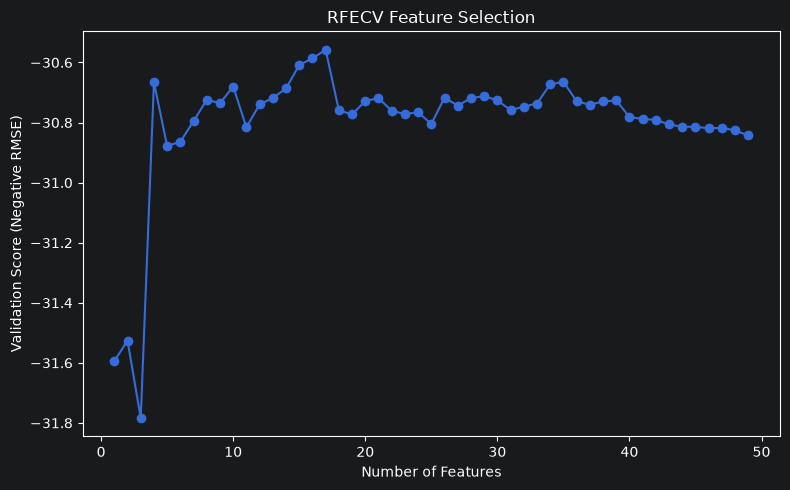

In [203]:
ridge_base_model_rfecv = Ridge(
    **ridge_regressor_params
)

select_features_with_rfecv(ALL_TRAINING_FEATURES, train_df, val_df, output_labels=target_label, model=ridge_base_model_rfecv)

**Observation:** RFECV selected **17 features**, retaining a broad mix of AQI history, pollutant levels and trends, weather variables, and seasonal information. The selected set will be evaluated with the finalized MLP to determine whether feature reduction improves Day 4 performance.

In [209]:
MLP_DAY_4_RFECV_FEATURES = [
  "aqi_today",
  "aqi_lag_1",
  "aqi_lag_2",
  "aqi_lag_3",
  "aqi_roll_mean_7",

  "pm25_today",
  "pm25_lag_1",
  "pm25_lag_2",
  "pm25_lag_3",
  "pm25_roll_mean_7",

  "o3_today",
  "o3_lag_1",
  "o3_lag_2",
  "o3_lag_3",
  "o3_roll_mean_7",

  "pm10_today",
  "pm10_lag_1",
  "pm10_lag_2",
  "pm10_lag_3",
  "pm10_roll_mean_7",

  "co_today",
  "so2_today",
  "no2_today",

  "temp_today",
  "temp_lag_1",

  "dew_pt_today",
  "dew_pt_lag_1",
]

mlp_base_model_4_rfecv = Sequential([
    Input(shape=(27,)),
    Dense(
        128,
        activation="relu",
        kernel_regularizer=l2(1e-3),
    ),
    Dropout(0.15),
    Dense(1, activation="linear"),
])

mlp_base_model_4_rfecv.compile(
    optimizer=Adam(learning_rate=5e-3),
    loss="huber",
)

mlp_base_model_4_rfecv, (mlp_base_rmse_4_rfecv, mlp_base_mae_4_rfecv, mlp_base_r2_4_rfecv) = train_and_evaluate_model(train_df,
                         val_df, label="MLP Base Model Day 4 RFECV", disable_plot=True, baseline=MLP_DAY_4_RFECV_FEATURES,
                         model=mlp_base_model_4_rfecv, output_labels=target_label,
                         compare_model=("MLP Base Model Day 4", (
                                        mlp_base_rmse_4, mlp_base_mae_4, mlp_base_r2_4
                         )),
                         deep_learning=mlp_base_model_fit_params)

Epoch 1/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 145.6262 - val_loss: 135.8887
Epoch 2/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 104.3605 - val_loss: 77.9846
Epoch 3/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 67.7447 - val_loss: 53.5008
Epoch 4/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 57.0476 - val_loss: 47.9543
Epoch 5/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 47.0766 - val_loss: 42.2990
Epoch 6/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 39.4442 - val_loss: 39.1919
Epoch 7/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 36.9726 - val_loss: 36.7288
Epoch 8/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 35.2456 - val_loss: 34.8130
Epoch 9/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 33.6944 - val_loss: 33.2925
Epoch 10/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 32.5194 - val_loss: 32.3352
Epoch 11/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 30.9624 - val_loss: 31.3832
Epoch 12/500
32/32 ━━━━━━━━━━━━━━━━━━

,Target,MLP Base Model Day 4 RMSE,MLP Base Model Day 4 MAE,MLP Base Model Day 4 R²,MLP Base Model Day 4 RFECV RMSE,MLP Base Model Day 4 RFECV MAE,MLP Base Model Day 4 RFECV R²
0,target_aqi_day4,32.686474,24.580612,0.397042,29.588678,21.768463,0.505915
1,Mean,32.686474,24.580612,0.397042,29.588678,21.768463,0.505915


**Observation:** The RFECV-selected feature set provided a substantial improvement, reducing RMSE from **32.69 → 29.59**, MAE from **24.58 → 21.77**, and increasing R² from **0.397 → 0.506**. Although Day 4 remains the most difficult forecasting horizon, feature selection improved performance considerably and brings the model above **0.50 R²**.